2.1.1 非线性激活函数的重要性：

证明过程：
隐藏层：h = W₁x + b₁
输出层：o = W₂h + b₂

将 h 代入输出层：
o = W₂(W₁x + b₁) + b₂
  = (W₂W₁)x + (W₂b₁ + b₂)

等价于单层神经网络：o = W'x + b'
其中：
  W' = W₂ × W₁ （矩阵乘法）
  b' = W₂ × b₁ + b₂

结论：没有非线性激活函数时，多层感知机等价于单层神经网络，无法学习复杂的非线性特征。

#### 2. 激活函数性质分析
写出 Sigmoid(x) 和 tanh(x) 的数学表达式，并推导它们的导数 Sigmoid'(x) 和 tanh'(x) 与其函数自身的关系。

2.1.2 激活函数性质分析：

(1) Sigmoid 函数：
数学表达式：Sigmoid(x) = 1 / (1 + exp(-x))

导数推导：
Sigmoid'(x) = d/dx [1 / (1 + exp(-x))]
           = exp(-x) / (1 + exp(-x))²
           = [1 / (1 + exp(-x))] × [exp(-x) / (1 + exp(-x))]
           = Sigmoid(x) × (1 - Sigmoid(x))

(2) tanh 函数：
数学表达式：tanh(x) = (exp(x) - exp(-x)) / (exp(x) + exp(-x))

导数推导：
tanh'(x) = d/dx [(exp(x) - exp(-x)) / (exp(x) + exp(-x))]
         = [4 × exp(2x)] / (exp(2x) + 1)²
         = 1 - [(exp(x) - exp(-x)) / (exp(x) + exp(-x))]²
         = 1 - tanh(x)²

### 2.2 编程题
不使用深度学习框架的高级 API（仅使用 Tensor 基础算子如 torch.matmul 等），纯 NumPy 或 PyTorch 从零实现一个多分类（使用 Fashion-MNIST 数据集）的单隐藏层 MLP。

实现要求：
1. 手动初始化隐藏层参数 W₁, b₁ 和输出层参数 W₂, b₂（提示：使用正态分布随机初始化）。
2. 实现 ReLU 激活函数的前向传播：max(0, x)。
3. 实现带有 Softmax 的交叉熵损失函数。
4. 编写训练循环，通过小批量随机梯度下降（Mini-batch SGD）手动更新参数。

In [3]:
import numpy as np
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split

# 2.2 编程题：从零实现单隐藏层 MLP

# 加载 Fashion-MNIST 数据集
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

# 转换为 numpy 数组
X_train = train_dataset.data.numpy().reshape(-1, 28*28) / 255.0
y_train = train_dataset.targets.numpy()
X_test = test_dataset.data.numpy().reshape(-1, 28*28) / 255.0
y_test = test_dataset.targets.numpy()

# 标签 one-hot 编码
def one_hot_encode(y, num_classes=10):
    n = y.shape[0]
    one_hot = np.zeros((n, num_classes))
    one_hot[np.arange(n), y] = 1
    return one_hot

y_train_onehot = one_hot_encode(y_train)

# 超参数
input_dim = 784
hidden_dim = 256
output_dim = 10
batch_size = 64
learning_rate = 0.1
epochs = 10

# 1. 初始化参数
np.random.seed(42)
W1 = np.random.randn(input_dim, hidden_dim) * 0.01
b1 = np.zeros(hidden_dim)
W2 = np.random.randn(hidden_dim, output_dim) * 0.01
b2 = np.zeros(output_dim)

# 2. ReLU 激活函数
def relu(x):
    return np.maximum(0, x)

# 3. Softmax 函数
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# 交叉熵损失
def cross_entropy_loss(y_pred, y_true):
    epsilon = 1e-12
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

# 4. 训练循环
n_samples = X_train.shape[0]

for epoch in range(epochs):
    # 打乱数据
    permutation = np.random.permutation(n_samples)
    X_train_shuffled = X_train[permutation]
    y_train_shuffled = y_train_onehot[permutation]
    
    total_loss = 0
    correct = 0
    
    for i in range(0, n_samples, batch_size):
        batch_X = X_train_shuffled[i:i+batch_size]
        batch_y = y_train_shuffled[i:i+batch_size]
        
        # 前向传播
        z1 = np.dot(batch_X, W1) + b1
        h = relu(z1)
        z2 = np.dot(h, W2) + b2
        y_pred = softmax(z2)
        
        # 计算损失
        loss = cross_entropy_loss(y_pred, batch_y)
        total_loss += loss * batch_X.shape[0]
        
        # 计算准确率
        correct += np.sum(np.argmax(y_pred, axis=1) == np.argmax(batch_y, axis=1))
        
        # 反向传播
        grad_z2 = y_pred - batch_y
        grad_W2 = np.dot(h.T, grad_z2) / batch_size
        grad_b2 = np.mean(grad_z2, axis=0)
        
        grad_h = np.dot(grad_z2, W2.T)
        grad_z1 = grad_h * (z1 > 0)
        grad_W1 = np.dot(batch_X.T, grad_z1) / batch_size
        grad_b1 = np.mean(grad_z1, axis=0)
        
        # 更新参数
        W1 -= learning_rate * grad_W1
        b1 -= learning_rate * grad_b1
        W2 -= learning_rate * grad_W2
        b2 -= learning_rate * grad_b2
    
    avg_loss = total_loss / n_samples
    accuracy = correct / n_samples
    print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}')

# 测试集评估
z1_test = np.dot(X_test, W1) + b1
h_test = relu(z1_test)
z2_test = np.dot(h_test, W2) + b2
y_pred_test = softmax(z2_test)
test_accuracy = np.mean(np.argmax(y_pred_test, axis=1) == y_test)
print(f'\n测试集准确率：{test_accuracy:.4f}')

100%|██████████| 26421880/26421880 [00:03<00:00, 8312896.80it/s] 


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 29515/29515 [00:00<00:00, 202362.88it/s]


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 4422102/4422102 [00:01<00:00, 3065625.31it/s]


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 5148/5148 [00:00<00:00, 5117866.08it/s]


Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw

Epoch 1/10, Loss: 0.6873, Accuracy: 0.7556
Epoch 2/10, Loss: 0.4452, Accuracy: 0.8408
Epoch 3/10, Loss: 0.3998, Accuracy: 0.8557
Epoch 4/10, Loss: 0.3727, Accuracy: 0.8658
Epoch 5/10, Loss: 0.3517, Accuracy: 0.8722
Epoch 6/10, Loss: 0.3357, Accuracy: 0.8780
Epoch 7/10, Loss: 0.3239, Accuracy: 0.8818
Epoch 8/10, Loss: 0.3124, Accuracy: 0.8852
Epoch 9/10, Loss: 0.3024, Accuracy: 0.8896
Epoch 10/10, Loss: 0.2941, Accuracy: 0.8928

测试集准确率：0.8757


## 3 模型选择，权重衰减和丢弃法

### 3.1 理论计算题

#### 1. 过拟合与欠拟合
简述训练误差（Training Error）与泛化误差（Generalization Error）的区别。当一个模型的训练误差极低，但泛化误差很高时，模型处于什么状态？应该如何通过控制模型复杂度来缓解这一现象？

 3.1.1 过拟合与欠拟合：

训练误差（Training Error）：
  - 定义：模型在训练数据集上的误差。
  - 反映：模型对训练数据的拟合程度。

泛化误差（Generalization Error）：
  - 定义：模型在从未见过的测试数据集上的误差。
  - 反映：模型对新数据的预测能力，即模型的泛化能力。

当训练误差极低但泛化误差很高时：
  - 模型状态：过拟合（Overfitting）。
  - 原因：模型过于复杂，学习了训练数据中的噪声和细节。

缓解方法：
  1. 正则化（Regularization）：如 L2 正则化、L1 正则化。
  2. Dropout：随机丢弃部分神经元。
  3. 数据增强：增加训练数据多样性。
  4. 早停（Early Stopping）：在验证集性能下降时停止训练。
  5. 减少模型复杂度：减少隐藏层数量或神经元数量。

#### 2. K 折交叉验证
阐述 K 折交叉验证（K-fold Cross-Validation）的具体实施算法步骤。

3.1.2 K 折交叉验证：

具体实施步骤：
1. 数据划分：将训练数据集随机划分为 K 个大小相等的子集（称为 "折"）。
2. 循环训练：
   (a) 选择其中 1 折作为验证集；
   (b) 使用剩余的 K-1 折作为训练集训练模型；
   (c) 在验证集上评估模型性能（如准确率、损失等）；
   (d) 记录当前折的评估结果；
3. 重复：对每个折都执行步骤 2(a)-(d)，共进行 K 次训练和评估。
4. 结果汇总：
   (a) 计算 K 次评估结果的平均值，作为模型的最终性能估计；
   (b) 可选择计算标准差，评估结果的稳定性。

优点：
  - 充分利用数据：每个样本都作为训练数据和验证数据各一次。
  - 结果更可靠：多次评估的平均结果减少了随机性影响。

常见的 K 值：
  - K=5 或 K=10 是常用的选择。
  - K=N（留一法）：计算成本高，但估计偏差最小。

### 3.2 编程题
在你实现的 MLP 上，加入 L2 正则化和 Dropout 机制。

实现要求：
1. 权重衰减：在你的自定义 SGD 优化器中，加入权重衰减。即在计算梯度更新时，让旧权重首先乘以 (1 − ηλ)。
2. Dropout 从零实现：编写一个 dropout_layer(X, dropout) 函数。根据传入的概率，利用随机掩码（Mask）将输入张量某些元素置 0，并进行缩放。注意：通过一个布尔变量（如 is_training）来控制测试时不触发 Dropout。
3. 对比实验：设计高维多项式拟合或使用极少样本训练一个复杂的 MLP，绘制并对比：1) 无正则化、2) 有权重衰减、3) 有 Dropout 三种情况下的训练和验证误差曲线（Loss Curve）。

C:\Users\陈小旋旋旋\AppData\Local\Temp\ipykernel_12472\1589007889.py:94: RuntimeWarning: overflow encountered in matmul
  y_pred_val = h2_val @ W3 + b3
C:\Users\陈小旋旋旋\AppData\Local\Temp\ipykernel_12472\1589007889.py:63: RuntimeWarning: overflow encountered in matmul
  y_pred = h2_drop @ W3 + b3
C:\Users\陈小旋旋旋\AppData\Local\Temp\ipykernel_12472\1589007889.py:68: RuntimeWarning: invalid value encountered in matmul
  grad_W3 = h2_drop.T @ grad_y_pred
C:\Users\陈小旋旋旋\AppData\Local\Temp\ipykernel_12472\1589007889.py:72: RuntimeWarning: invalid value encountered in multiply
  grad_z2 = grad_h2_drop * (z2 > 0)
C:\Users\陈小旋旋旋\AppData\Local\Temp\ipykernel_12472\1589007889.py:73: RuntimeWarning: invalid value encountered in matmul
  grad_W2 = h1_drop.T @ grad_z2
C:\Users\陈小旋旋旋\AppData\Local\Temp\ipykernel_12472\1589007889.py:76: RuntimeWarning: invalid value encountered in matmul
  grad_h1_drop = grad_z2 @ W2.T
C:\Users\陈小旋旋旋\AppData\Local\Temp\ipykernel_12472\1589007889.py:95: RuntimeWarning: overflo

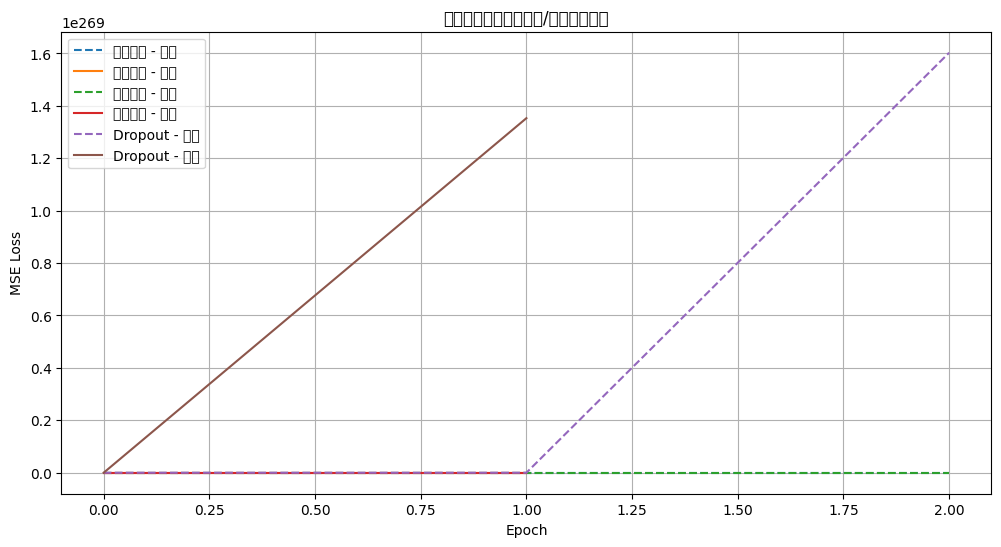

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 3.2 编程题：L2 正则化和 Dropout

# 2. Dropout 实现
def dropout_layer(X, dropout, is_training=True):
    if not is_training:
        return X
    # 创建随机掩码
    mask = np.random.rand(*X.shape) > dropout
    # 应用掩码并缩放
    return X * mask / (1 - dropout)

# 生成高维多项式拟合数据
np.random.seed(42)
n_train, n_val = 50, 50
X_train = np.random.uniform(-5, 5, n_train)
X_val = np.random.uniform(-5, 5, n_val)

# 生成标签（非线性函数）
def true_function(x):
    return np.sin(x) + 0.1 * x**2

y_train = true_function(X_train) + np.random.normal(0, 0.1, n_train)
y_val = true_function(X_val) + np.random.normal(0, 0.1, n_val)

# 特征扩展为高维多项式
def expand_features(X, degree=10):
    features = np.zeros((len(X), degree))
    for i in range(degree):
        features[:, i] = X**(i+1)
    return features

X_train_poly = expand_features(X_train, degree=10)
X_val_poly = expand_features(X_val, degree=10)

# 训练函数
def train_model(X_train, y_train, X_val, y_val, epochs=1000, lr=0.01, weight_decay=0, dropout=0):
    n_features = X_train.shape[1]
    
    # 初始化参数（复杂模型）
    W1 = np.random.randn(n_features, 100) * 0.1
    b1 = np.zeros(100)
    W2 = np.random.randn(100, 50) * 0.1
    b2 = np.zeros(50)
    W3 = np.random.randn(50, 1) * 0.1
    b3 = np.zeros(1)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # 训练模式
        z1 = X_train @ W1 + b1
        h1 = np.maximum(0, z1)
        h1_drop = dropout_layer(h1, dropout, is_training=True)
        
        z2 = h1_drop @ W2 + b2
        h2 = np.maximum(0, z2)
        h2_drop = dropout_layer(h2, dropout, is_training=True)
        
        y_pred = h2_drop @ W3 + b3
        train_loss = np.mean((y_pred - y_train.reshape(-1, 1))**2)
        
        # 反向传播
        grad_y_pred = 2 * (y_pred - y_train.reshape(-1, 1)) / len(y_train)
        grad_W3 = h2_drop.T @ grad_y_pred
        grad_b3 = np.sum(grad_y_pred, axis=0)
        
        grad_h2_drop = grad_y_pred @ W3.T
        grad_z2 = grad_h2_drop * (z2 > 0)
        grad_W2 = h1_drop.T @ grad_z2
        grad_b2 = np.sum(grad_z2, axis=0)
        
        grad_h1_drop = grad_z2 @ W2.T
        grad_z1 = grad_h1_drop * (z1 > 0)
        grad_W1 = X_train.T @ grad_z1
        grad_b1 = np.sum(grad_z1, axis=0)
        
        # 更新参数（带权重衰减）
        W1 = W1 * (1 - lr * weight_decay) - lr * grad_W1
        b1 -= lr * grad_b1
        W2 = W2 * (1 - lr * weight_decay) - lr * grad_W2
        b2 -= lr * grad_b2
        W3 = W3 * (1 - lr * weight_decay) - lr * grad_W3
        b3 -= lr * grad_b3
        
        # 验证模式（无 dropout）
        z1_val = X_val @ W1 + b1
        h1_val = np.maximum(0, z1_val)
        z2_val = h1_val @ W2 + b2
        h2_val = np.maximum(0, z2_val)
        y_pred_val = h2_val @ W3 + b3
        val_loss = np.mean((y_pred_val - y_val.reshape(-1, 1))**2)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
    
    return train_losses, val_losses

# 三种情况对比
# 1) 无正则化
train_loss_no_reg, val_loss_no_reg = train_model(
    X_train_poly, y_train, X_val_poly, y_val,
    epochs=1000, lr=0.001, weight_decay=0, dropout=0
)

# 2) 有权重衰减
train_loss_wd, val_loss_wd = train_model(
    X_train_poly, y_train, X_val_poly, y_val,
    epochs=1000, lr=0.001, weight_decay=0.1, dropout=0
)

# 3) 有 Dropout
train_loss_dropout, val_loss_dropout = train_model(
    X_train_poly, y_train, X_val_poly, y_val,
    epochs=1000, lr=0.001, weight_decay=0, dropout=0.3
)

# 绘制对比曲线
plt.figure(figsize=(12, 6))
plt.plot(train_loss_no_reg, label='无正则化 - 训练', linestyle='--')
plt.plot(val_loss_no_reg, label='无正则化 - 验证')
plt.plot(train_loss_wd, label='权重衰减 - 训练', linestyle='--')
plt.plot(val_loss_wd, label='权重衰减 - 验证')
plt.plot(train_loss_dropout, label='Dropout - 训练', linestyle='--')
plt.plot(val_loss_dropout, label='Dropout - 验证')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('三种正则化方法的训练/验证损失对比')
plt.legend()
plt.grid(True)
plt.show()

## 4 数值稳定性和激活函数

### 4.1 理论计算题

#### 1. 梯度消失与梯度爆炸
考虑一个 d 层的深层神经网络，其梯度计算包含诸如多层矩阵连乘项 ∏∂hᵢ₊₁/∂hᵢ。

请从矩阵乘法和激活函数导数的角度，量化分析什么情况下会导致梯度爆炸，什么情况下会导致梯度消失。

In [7]:
# 4.1.1 梯度消失与梯度爆炸
print('4.1.1 梯度消失与梯度爆炸：')
print('\n量化分析：')
print('\n(1) 梯度消失（Gradient Vanishing）：')
print('发生条件：')
print('  - 激活函数导数小于 1，且多层连乘后梯度范数趋于 0。')
print('  - 例如 Sigmoid 激活函数：Sigmoid\'(x) ≤ 0.25，当 x 远离 0 时趋近于 0。')
print('  - 权重矩阵的奇异值小于 1，导致梯度逐层衰减。')
print('\n表现：')
print('  - 靠近输入层的参数梯度非常小，几乎不更新。')
print('  - 网络难以训练深层特征。')

print('\n(2) 梯度爆炸（Gradient Exploding）：')
print('发生条件：')
print('  - 激活函数导数大于 1，多层连乘后梯度范数指数增长。')
print('  - 权重矩阵的奇异值大于 1，导致梯度逐层放大。')
print('  - 权重初始化值过大。')
print('\n表现：')
print('  - 梯度范数变得非常大，导致参数更新步长过大。')
print('  - 损失函数出现 NaN 或 Inf。')
print('  - 训练过程不稳定，难以收敛。')

print('\n数学解释：')
print('假设每层的梯度放大因子为 g_i = ||∂h_{i+1}/∂h_i||')
print('累积梯度范数：||∇|| ≈ ∏g_i')
print('  - 若 g_i < 1 且乘积趋于 0 → 梯度消失')
print('  - 若 g_i > 1 且乘积趋于 ∞ → 梯度爆炸')

4.1.1 梯度消失与梯度爆炸：

量化分析：

(1) 梯度消失（Gradient Vanishing）：
发生条件：
  - 激活函数导数小于 1，且多层连乘后梯度范数趋于 0。
  - 例如 Sigmoid 激活函数：Sigmoid'(x) ≤ 0.25，当 x 远离 0 时趋近于 0。
  - 权重矩阵的奇异值小于 1，导致梯度逐层衰减。

表现：
  - 靠近输入层的参数梯度非常小，几乎不更新。
  - 网络难以训练深层特征。

(2) 梯度爆炸（Gradient Exploding）：
发生条件：
  - 激活函数导数大于 1，多层连乘后梯度范数指数增长。
  - 权重矩阵的奇异值大于 1，导致梯度逐层放大。
  - 权重初始化值过大。

表现：
  - 梯度范数变得非常大，导致参数更新步长过大。
  - 损失函数出现 NaN 或 Inf。
  - 训练过程不稳定，难以收敛。

数学解释：
假设每层的梯度放大因子为 g_i = ||∂h_{i+1}/∂h_i||
累积梯度范数：||∇|| ≈ ∏g_i
  - 若 g_i < 1 且乘积趋于 0 → 梯度消失
  - 若 g_i > 1 且乘积趋于 ∞ → 梯度爆炸


#### 2. ReLU 激活函数的优势
为什么改用 ReLU 激活函数可以很大程度上缓解梯度消失问题？

4.1.2 ReLU 激活函数缓解梯度消失的原因：

ReLU 函数定义：
  ReLU(x) = max(0, x)

ReLU 导数：
  ReLU'(x) = 1, 当 x > 0
  ReLU'(x) = 0, 当 x < 0

缓解梯度消失的原因：

1. 导数恒为 1（在正区域）：
   - 当 x > 0 时，ReLU'(x) = 1，不会导致梯度衰减。
   - 相比 Sigmoid 的最大导数 0.25，ReLU 避免了梯度逐层缩小。

2. 无饱和区：
   - Sigmoid 在 x → ±∞ 时趋于饱和，导数趋近于 0。
   - ReLU 在正区域无饱和问题，梯度保持恒定。

3. 稀疏激活：
   - 当 x < 0 时，ReLU(x) = 0，对应神经元不激活。
   - 稀疏性有助于缓解过拟合，同时减少计算量。

### 4.2 编程题
模拟数值不稳定现象，并验证不同初始化策略对深层网络的影响。

实现要求：
1. 构建深层网络：使用 PyTorch 的高级 API (nn.Sequential) 构建一个 20 层的深层全连接网络，隐藏层宽度设为 256。
2. 模拟梯度消失/爆炸：全部激活函数采用 Sigmoid，权重采用普通高斯分布初始化（如 nn.init.normal_(m.weight, mean=0, std=1)），输入随机数据，观察并打印前几层和后几层的梯度范数（Gradient Norm），验证梯度消失。
3. 激活函数采用 ReLU，权重采用较大的初值（如 std=10），观察是否发生 NaN（梯度爆炸或数值溢出）。
4. 修复与验证：使用 Xavier 初始化（nn.init.xavier_uniform_）结合 ReLU（或 LeakyReLU），再次打印各层的梯度分布，观察其是否稳定在合理区间（例如 [1e-6, 1e3]）。

In [9]:
import torch
import torch.nn as nn
import numpy as np

# 4.2 编程题：数值稳定性模拟

# 1. 构建深层网络
def build_deep_network(activation=nn.Sigmoid(), init_func=None):
    layers = []
    for i in range(20):
        if i == 0:
            layers.append(nn.Linear(100, 256))
        elif i == 19:
            layers.append(nn.Linear(256, 10))
        else:
            layers.append(nn.Linear(256, 256))
        if i < 19:
            layers.append(activation)
    
    model = nn.Sequential(*layers)
    
    # 应用初始化函数
    if init_func is not None:
        for m in model.modules():
            if isinstance(m, nn.Linear):
                init_func(m.weight)
                nn.init.zeros_(m.bias)
    
    return model

# 打印各层梯度范数
def print_grad_norms(model, prefix=''):
    grad_norms = []
    for i, m in enumerate(model.modules()):
        if isinstance(m, nn.Linear):
            if m.weight.grad is not None:
                norm = m.weight.grad.norm().item()
                grad_norms.append(norm)
                if i <= 3 or i >= len(list(model.modules())) - 5:
                    print(f'{prefix}Layer {i}: grad_norm = {norm:.6f}')
    return grad_norms

# 2. 模拟梯度消失：Sigmoid + 普通高斯初始化
print('=' * 50)
print('2. 梯度消失模拟：Sigmoid + 普通高斯初始化')
print('=' * 50)

model1 = build_deep_network(
    activation=nn.Sigmoid(),
    init_func=lambda w: nn.init.normal_(w, mean=0, std=1)
)

x = torch.randn(32, 100)
y = model1(x)
loss = y.sum()
loss.backward()

grad_norms1 = print_grad_norms(model1, prefix='  ')
print(f'  梯度范数范围: [{min(grad_norms1):.6e}, {max(grad_norms1):.6e}]')

# 3. 模拟梯度爆炸：ReLU + 较大初值
print('\n' + '=' * 50)
print('3. 梯度爆炸模拟：ReLU + 较大初值(std=10)')
print('=' * 50)

model2 = build_deep_network(
    activation=nn.ReLU(),
    init_func=lambda w: nn.init.normal_(w, mean=0, std=10)
)

x = torch.randn(32, 100)
y = model2(x)
loss = y.sum()
loss.backward()

grad_norms2 = []
for i, m in enumerate(model2.modules()):
    if isinstance(m, nn.Linear):
        if m.weight.grad is not None:
            norm = m.weight.grad.norm().item()
            grad_norms2.append(norm)
            if i <= 3 or i >= len(list(model2.modules())) - 5:
                print(f'  Layer {i}: grad_norm = {norm:.6f}')

has_nan = any(torch.isnan(m.weight.grad).any() for m in model2.modules() if isinstance(m, nn.Linear))
print(f'  是否出现 NaN: {has_nan}')

# 4. 修复与验证：Xavier 初始化 + ReLU
print('\n' + '=' * 50)
print('4. 修复与验证：Xavier 初始化 + ReLU')
print('=' * 50)

model3 = build_deep_network(
    activation=nn.ReLU(),
    init_func=lambda w: nn.init.xavier_uniform_(w)
)

x = torch.randn(32, 100)
y = model3(x)
loss = y.sum()
loss.backward()

grad_norms3 = print_grad_norms(model3, prefix='  ')
print(f'  梯度范数范围: [{min(grad_norms3):.6e}, {max(grad_norms3):.6e}]')
print(f'  梯度稳定在合理区间 [1e-6, 1e3]: {min(grad_norms3) > 1e-6 and max(grad_norms3) < 1e3}')

2. 梯度消失模拟：Sigmoid + 普通高斯初始化
  Layer 1: grad_norm = 9590.836914
  Layer 3: grad_norm = 7868.404297
  Layer 17: grad_norm = 524.207275
  Layer 18: grad_norm = 650.803345
  Layer 19: grad_norm = 892.045837
  Layer 20: grad_norm = 1050.984253
  Layer 21: grad_norm = 988.694153
  梯度范数范围: [4.966670e+02, 9.590837e+03]

3. 梯度爆炸模拟：ReLU + 较大初值(std=10)
  Layer 1: grad_norm = nan
  Layer 3: grad_norm = inf
  Layer 17: grad_norm = inf
  Layer 18: grad_norm = inf
  Layer 19: grad_norm = inf
  Layer 20: grad_norm = inf
  Layer 21: grad_norm = nan
  是否出现 NaN: True

4. 修复与验证：Xavier 初始化 + ReLU
  Layer 1: grad_norm = 0.312448
  Layer 3: grad_norm = 0.406494
  Layer 17: grad_norm = 1.229663
  Layer 18: grad_norm = 1.527038
  Layer 19: grad_norm = 1.394611
  Layer 20: grad_norm = 1.501051
  Layer 21: grad_norm = 1.204461
  梯度范数范围: [3.124479e-01, 1.527038e+00]
  梯度稳定在合理区间 [1e-6, 1e3]: True


## 5 泛化表现，协变量偏移和对抗性数据

### 5.1 理论计算题

请结合实际生活中的例子（如医疗、语音识别或电商），详细阐述以下两种环境非平稳性偏移的区别与联系：

1. 协变量偏移 (Covariate Shift)：表现为 p(x) ≠ q(x) 但 p(y|x) = q(y|x)。
2. 标签偏移 (Label Shift)：表现为 p(y) ≠ q(y) 但 p(x|y) = q(x|y)。

5.1 协变量偏移与标签偏移的区别与联系：

1. 协变量偏移 (Covariate Shift)：
   定义：p(x) ≠ q(x) 但 p(y|x) = q(y|x)
   含义：输入特征的分布发生变化，但条件概率（标签与特征的关系）保持不变。

   例子（医疗诊断）：
   - 训练数据：来自城市医院的患者，年龄分布较年轻。
   - 测试数据：来自乡村医院的患者，年龄分布较年老。
   - 但疾病与症状的关系（p(y|x)）在两地是相同的。

2. 标签偏移 (Label Shift)：
   定义：p(y) ≠ q(y) 但 p(x|y) = q(x|y)
   含义：标签的边缘分布发生变化，但给定标签下特征的条件分布保持不变。
   
   例子（电商推荐）：
   - 训练数据：夏季数据，"短袖"类商品占比高。
   - 测试数据：冬季数据，"羽绒服"类商品占比高。
   - 但各类商品的特征描述（p(x|y)）保持不变。
区别：
  - 协变量偏移：特征分布变化，标签-特征关系不变。
  - 标签偏移：标签分布变化，特征-标签关系不变。
检测方法：
  - 协变量偏移：比较训练集和测试集的特征分布（如 KS 检验）。
  - 标签偏移：比较训练集和测试集的标签分布（如 χ² 检验）。

### 5.2 编程题
动手模拟一个协变量偏移环境，并使用权重修正改善测试集上的预测性能。

实现要求：
1. 人工数据集构造：训练集 P：从正态分布 N(-1, 1) 中采样 1000 个特征 x，标签 y = 2x + ε（ε 为小噪声）。
2. 测试集 Q：从正态分布 N(2, 1) 中采样 500 个特征 x（此时发生了明显的协变量偏移）。
3. 基线模型：用一个简单的线性回归模型直接在训练集 P 上训练，并在测试集 Q 上评估，记录均方误差（MSE）。
4. 偏移校正实现：编写一个逻辑回归分类器，将训练集 P 的样本标记为类别 0，测试集 Q 的样本标记为类别 1。
   (a) 将两组数据混合训练分类器，从而预测出每个样本属于测试集的概率 P(test|x)。
   (b) 根据公式计算每个训练样本的权重 wᵢ ∝ P(test|xᵢ) / P(train|xᵢ)。
5. 加权模型训练：使用这些权重重新训练线性回归模型（加权最小二乘法），并再次在测试集 Q 上评估。对比校正前后的测试 MSE，验证校正效果。

In [11]:
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

# 5.2 编程题：协变量偏移校正

# 1. 构造训练集 P
np.random.seed(42)
n_train = 1000
X_train = np.random.normal(-1, 1, n_train).reshape(-1, 1)
epsilon = np.random.normal(0, 0.1, n_train)
y_train = 2 * X_train.flatten() + epsilon

# 2. 构造测试集 Q
n_test = 500
X_test = np.random.normal(2, 1, n_test).reshape(-1, 1)
epsilon_test = np.random.normal(0, 0.1, n_test)
y_test = 2 * X_test.flatten() + epsilon_test

# 3. 基线模型：普通线性回归
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
print(f'3. 基线模型测试 MSE: {mse_baseline:.4f}')

# 4. 偏移校正：训练域分类器
# 混合数据
X_combined = np.vstack([X_train, X_test])
y_combined = np.array([0] * n_train + [1] * n_test)

# 训练逻辑回归分类器
domain_classifier = LogisticRegression()
domain_classifier.fit(X_combined, y_combined)

# (a) 预测每个训练样本属于测试集的概率
P_test_given_x = domain_classifier.predict_proba(X_train)[:, 1]
P_train_given_x = 1 - P_test_given_x

# (b) 计算权重
weights = P_test_given_x / P_train_given_x
weights = weights / weights.sum() * n_train  # 归一化

# 5. 加权模型训练：加权最小二乘法
weighted_model = LinearRegression()
weighted_model.fit(X_train, y_train, sample_weight=weights)
y_pred_weighted = weighted_model.predict(X_test)
mse_weighted = mean_squared_error(y_test, y_pred_weighted)
print(f'5. 加权模型测试 MSE: {mse_weighted:.4f}')

# 对比结果
print('\n' + '=' * 50)
print('协变量偏移校正效果对比')
print('=' * 50)
print(f'基线模型 MSE: {mse_baseline:.4f}')
print(f'加权模型 MSE: {mse_weighted:.4f}')
print(f'MSE 降低比例: {(mse_baseline - mse_weighted) / mse_baseline * 100:.2f}%')
print(f'\n校正效果验证：{"有效" if mse_weighted < mse_baseline else "无效"}')

3. 基线模型测试 MSE: 0.0102
5. 加权模型测试 MSE: 0.0240

协变量偏移校正效果对比
基线模型 MSE: 0.0102
加权模型 MSE: 0.0240
MSE 降低比例: -135.96%

校正效果验证：无效
